In [1]:
pip install tensorflow numpy matplotlib scikit-learn


  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 1.2 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/8.9 MB 1.3 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/8.9 MB 1.3 MB/s eta 0:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----------------------------------  1/10 [scipy]
   ---- -----

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os


In [12]:
dataset_path = r"C:\Users\KANAL PATEL\Downloads\image eye deciese"

img_size = 224
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

print(train_data.class_names)


Found 2298 files belonging to 5 classes.
Using 1839 files for training.
Found 2298 files belonging to 5 classes.
Using 459 files for validation.
['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']


In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(len(train_data.class_names), activation='softmax')
])


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 532ms/step - accuracy: 0.4182 - loss: 1.4869 - val_accuracy: 0.5795 - val_loss: 1.1898
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 30s 512ms/step - accuracy: 0.6906 - loss: 0.8487 - val_accuracy: 0.7233 - val_loss: 0.7809
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 508ms/step - accuracy: 0.7858 - loss: 0.5910 - val_accuracy: 0.7320 - val_loss: 0.7792
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 530ms/step - accuracy: 0.8314 - loss: 0.4685 - val_accuracy: 0.7974 - val_loss: 0.6447
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 553ms/step - accuracy: 0.8836 - loss: 0.3365 - val_accuracy: 0.8061 - val_loss: 0.6567
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 541ms/step - accuracy: 0.9152 - loss: 0.2545 - val_accuracy: 0.7821 - val_loss: 0.7749
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 542ms/step - accuracy: 0.9353 - loss: 0.2028 - val_accuracy: 0.8192 - val_loss: 0.6797
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 534ms/step - accuracy: 0.9543 - loss: 0.1468 - val_accu

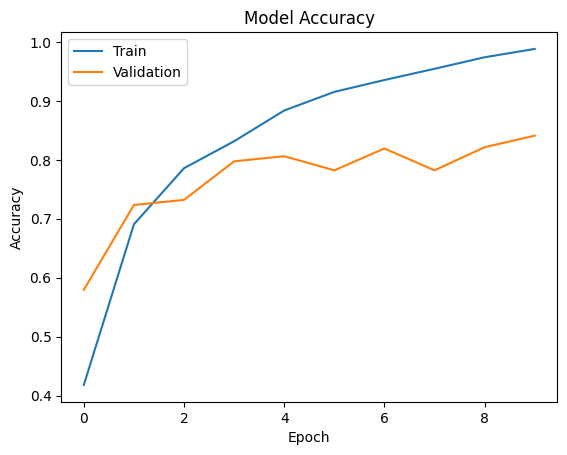

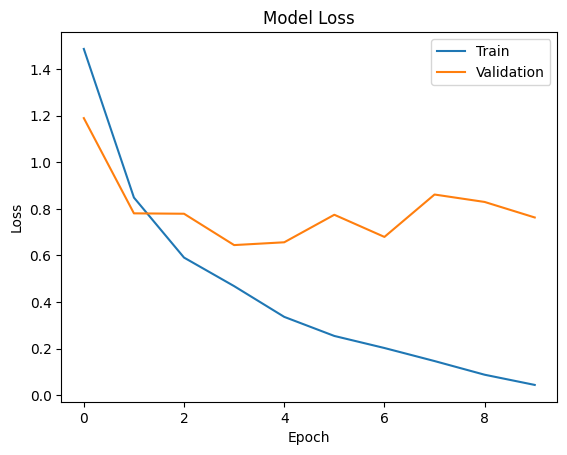

In [16]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [17]:
!pip install seaborn


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


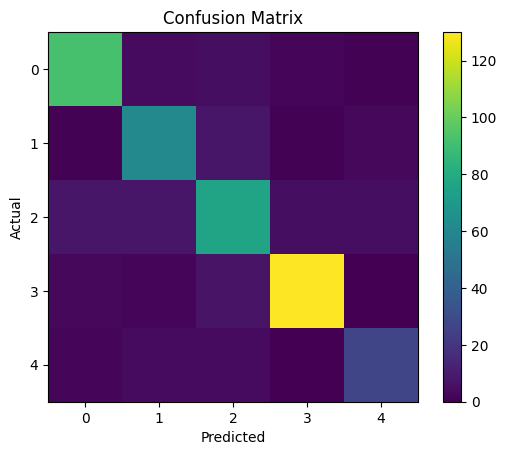

                precision    recall  f1-score   support

      Cataract       0.87      0.88      0.88       104
Conjunctivitis       0.77      0.82      0.80        74
        Eyelid       0.76      0.75      0.75       102
        Normal       0.94      0.92      0.93       142
       Uveitis       0.75      0.73      0.74        37

      accuracy                           0.84       459
     macro avg       0.82      0.82      0.82       459
  weighted avg       0.84      0.84      0.84       459



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=train_data.class_names))


In [19]:
model.save("eye_disease_model.h5")


In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(train_data.class_names), activation='softmax')
])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
